In [2]:
from shared.main import * 

In [ ]:
decision_trials[['onset', 'dimension', 'character_role_num', 'character_decision_num']]

,onset,decision_num,dimension,character_role_num,character_decision_num
0,55.905,1,affil,1,1
1,71.885,2,affil,1,2
2,91.864,3,affil,1,3
3,119.819,4,power,1,4
4,139.786,5,affil,2,1
...,...,...,...,...,...
58,1417.692,59,power,4,12
59,1439.659,60,power,3,9
60,1459.638,61,power,3,10
61,1479.605,62,power,3,11


# task structure

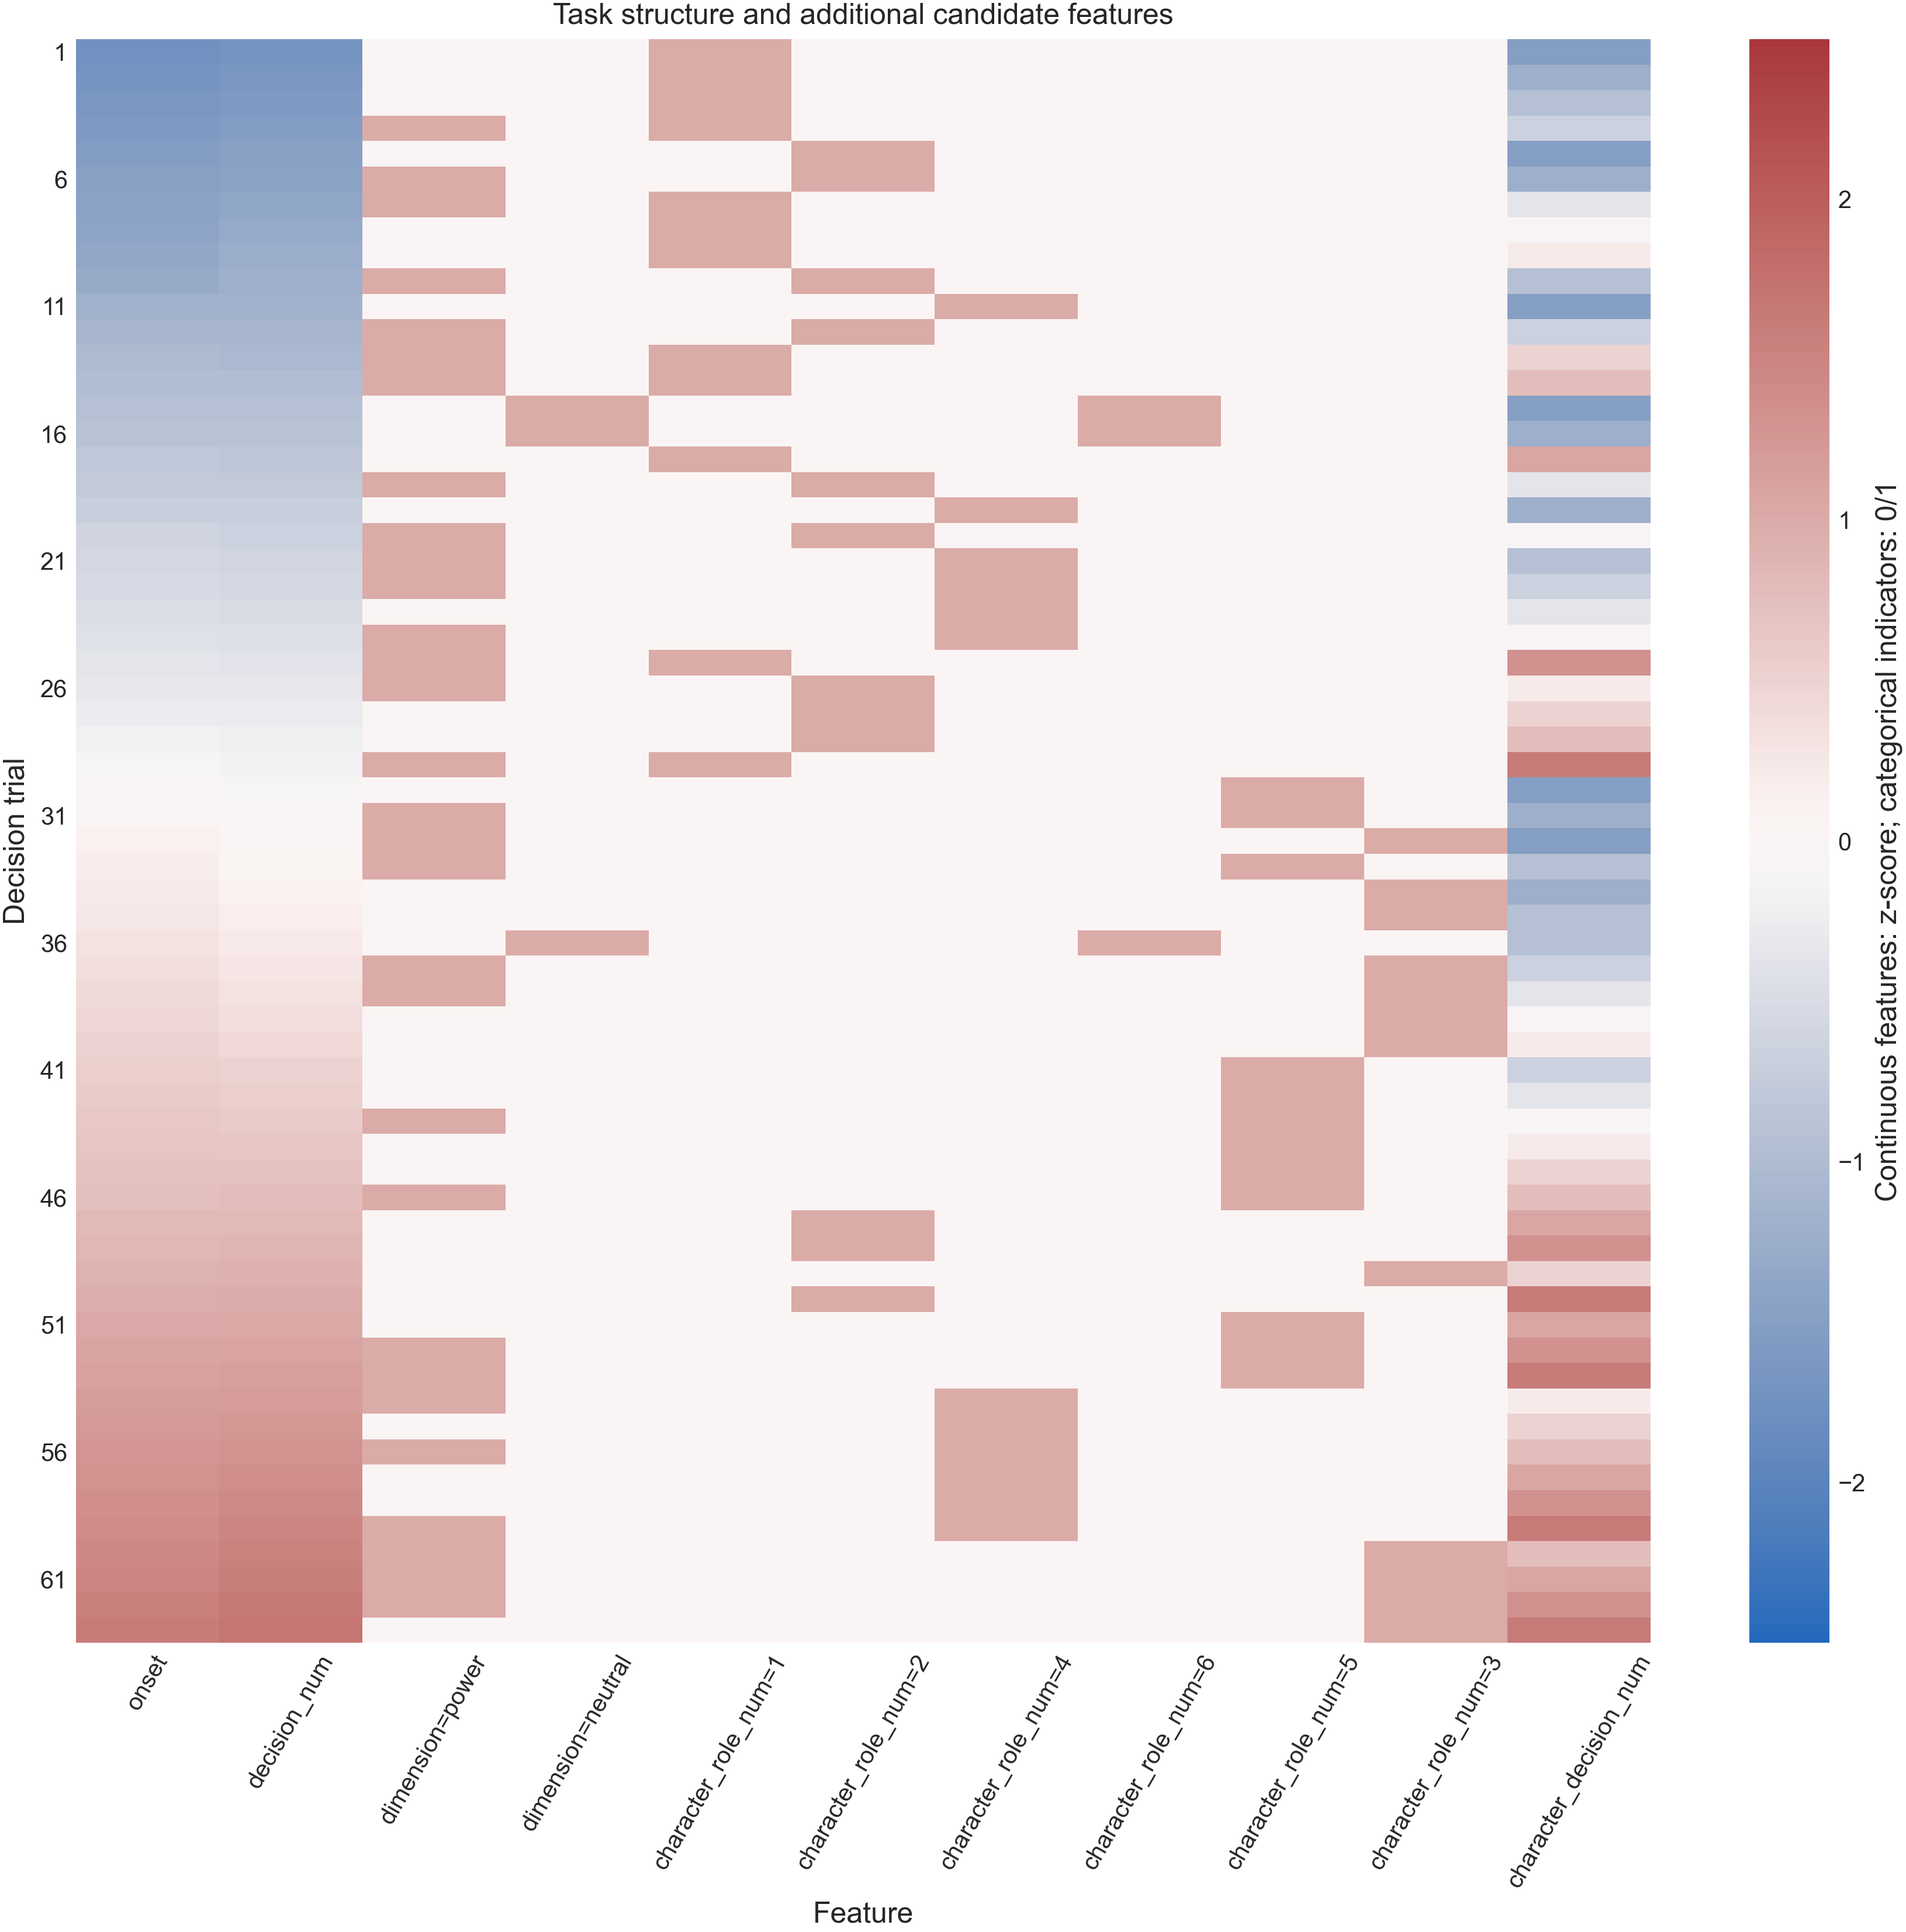

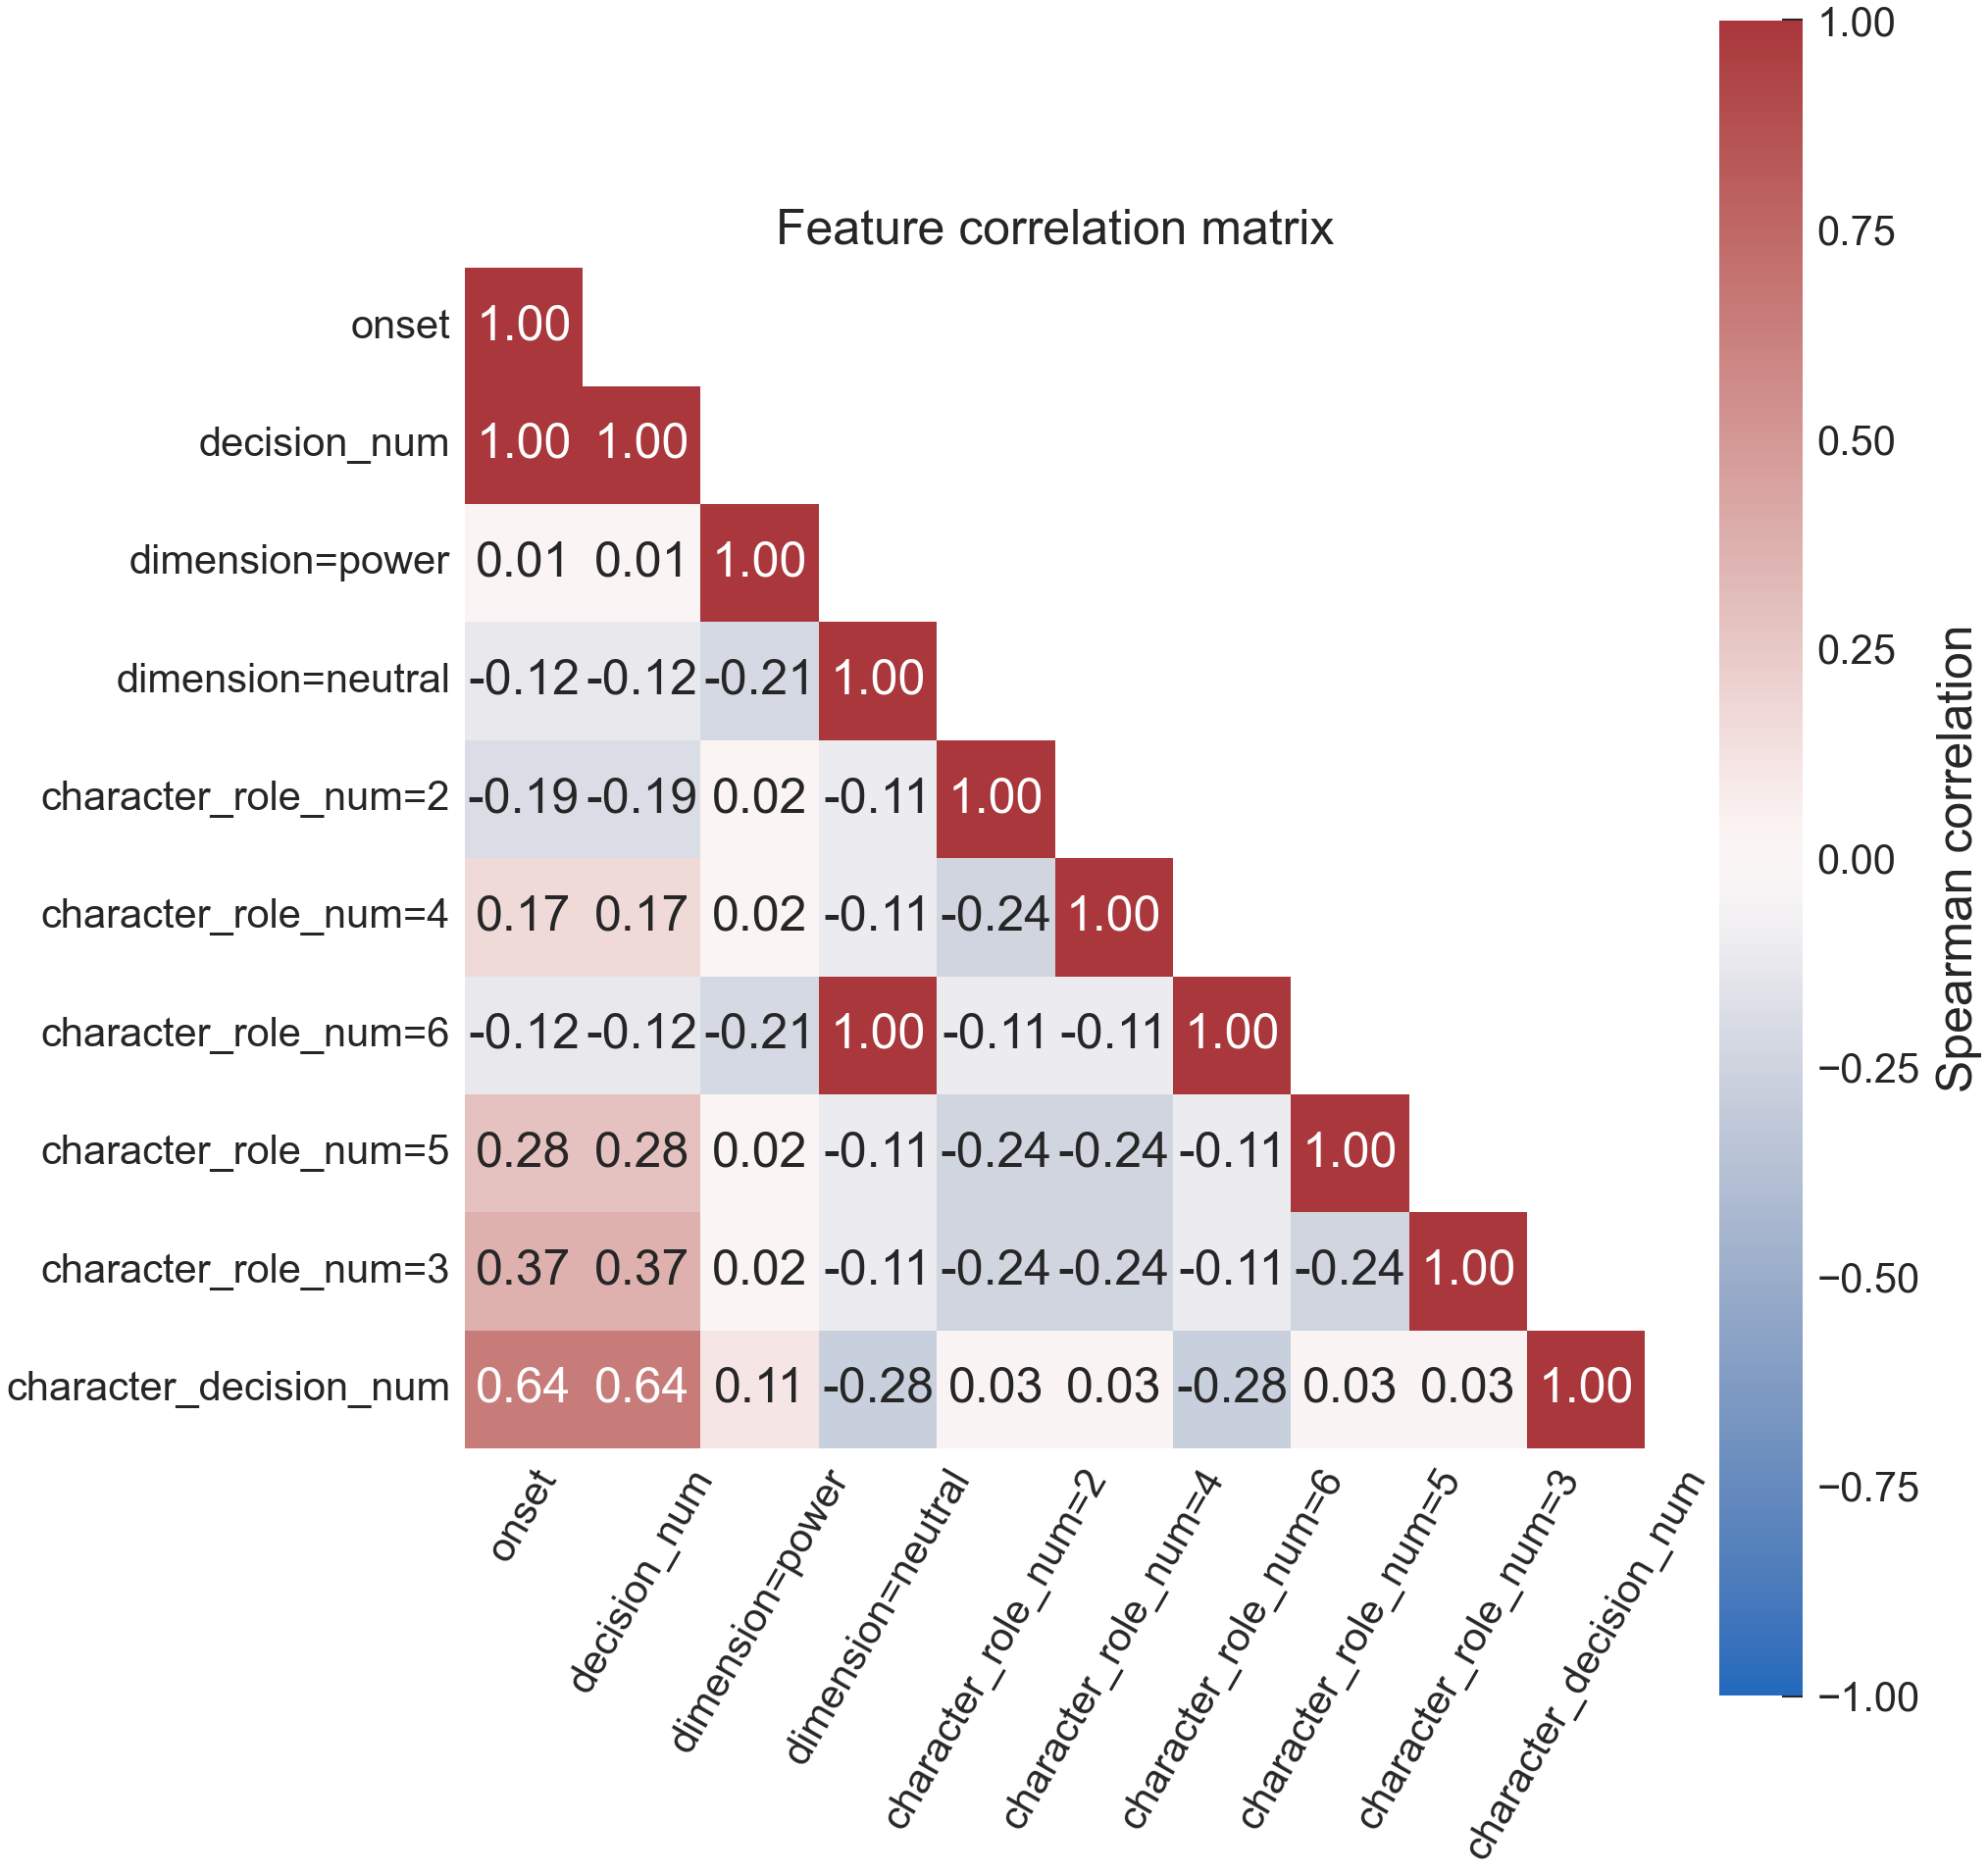

In [ ]:
from __future__ import annotations

from collections.abc import Sequence

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def _zscore_for_heatmap(series: pd.Series) -> pd.Series:
    """Z-score a numeric feature. Constant features become zero."""
    x = pd.to_numeric(series, errors="coerce").astype(float)
    sd = x.std(ddof=0)

    if not np.isfinite(sd) or sd == 0:
        return pd.Series(0.0, index=series.index, name=series.name)

    return ((x - x.mean()) / sd).rename(series.name)

def _categorical_dummies(
    series: pd.Series,
    prefix: str,
    *,
    drop_first: bool = False,
    preferred_order: Sequence[str] | None = None,
) -> pd.DataFrame:
    """One-hot encode a categorical feature while preserving category order."""
    s = series.astype("string").fillna("<missing>")
    observed = list(pd.unique(s))

    categories: list[str] = []

    if preferred_order is not None:
        preferred = [str(value) for value in preferred_order]
        categories.extend([value for value in preferred if value in observed])

    categories.extend(
        value for value in observed
        if value not in categories
    )

    categorical = pd.Categorical(
        s,
        categories=categories,
        ordered=True,
    )

    dummies = pd.get_dummies(
        categorical,
        prefix=prefix,
        prefix_sep="=",
        drop_first=drop_first,
        dtype=float,
    )

    dummies.index = series.index
    return dummies

def _drop_constant_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Remove columns with fewer than two observed values."""
    if frame.empty:
        return frame.copy()

    keep = frame.nunique(dropna=True) > 1
    return frame.loc[:, keep]

def _linear_r2(
    y: pd.Series,
    X: pd.DataFrame,
) -> tuple[float, float, int]:
    """
    Fit descriptive OLS with NumPy and return:
        R², adjusted R², number of observations.
    """
    target = pd.to_numeric(
        y,
        errors="coerce",
    ).rename("__target__")

    predictors = X.copy()

    for column in predictors.columns:
        predictors[column] = pd.to_numeric(
            predictors[column],
            errors="coerce",
        )

    predictors = _drop_constant_columns(predictors)

    model_data = pd.concat(
        [target, predictors],
        axis=1,
    ).dropna()

    if (
        model_data.empty
        or model_data["__target__"].nunique() < 2
    ):
        return np.nan, np.nan, len(model_data)

    y_array = model_data.pop("__target__").to_numpy(dtype=float)
    X_array = model_data.to_numpy(dtype=float)

    # Add intercept.
    X_array = np.column_stack(
        [np.ones(len(X_array)), X_array]
    )

    rank = np.linalg.matrix_rank(X_array)

    if len(y_array) <= rank:
        return np.nan, np.nan, len(y_array)

    coefficients, *_ = np.linalg.lstsq(
        X_array,
        y_array,
        rcond=None,
    )

    predicted = X_array @ coefficients

    ss_residual = np.sum((y_array - predicted) ** 2)
    ss_total = np.sum((y_array - y_array.mean()) ** 2)

    if ss_total <= 0:
        return np.nan, np.nan, len(y_array)

    r2 = 1.0 - (ss_residual / ss_total)
    r2 = float(np.clip(r2, 0.0, 1.0))

    residual_df = len(y_array) - rank

    adjusted_r2 = (
        1.0
        - (1.0 - r2)
        * (len(y_array) - 1)
        / residual_df
        if residual_df > 0
        else np.nan
    )

    return r2, float(adjusted_r2), len(y_array)

# MAIN VISUALIZER / ANALYZER
def task_structure_visualizer(
    decision_trials: pd.DataFrame,
    additional_features: pd.DataFrame | None = None,
    *,
    onset_col: str = "onset",
    decision_col: str = "decision_num",
    dimension_col: str = "dimension",
    character_col: str = "character_role_num",
    character_decision_col: str = "character_decision_num",
    additional_categorical_cols: Sequence[str] = (),
    dimension_order: Sequence[str] = ("affil", "power"),
    correlation_method: str = "spearman",
    clip_z: float = 2.5,
    show: bool = True,
) -> dict[str, object]:
    """
    Create:

    1. One large trial × feature heatmap.
    2. One separate feature-correlation heatmap.
    3. Descriptive R² analyses showing how much each additional
       continuous predictor is explained by task structure.
    4. Basic task-integrity checks.

    Parameters
    ----------
    decision_trials
        Trial-level DataFrame containing at least:
            onset
            decision_num
            dimension
            character_role_num
            character_decision_num

    additional_features
        Optional DataFrame with the same number and order of rows as
        decision_trials. Each column should contain one scalar feature
        per trial.

        Examples:
            option_semantic_distance
            narrative_change
            affiliation_projection
            power_projection
            semantic_update

    additional_categorical_cols
        Names of integer-coded or numeric-looking columns in
        additional_features that should be treated as categorical.

        String, boolean, and category columns are automatically
        treated as categorical.

    Returns
    -------
    Dictionary containing:
        ordered_data
        heatmap_matrix
        correlation_data
        correlation_matrix
        additional_structure_r2
        additional_feature_types
        checks
        heatmap_figure
        correlation_figure
    """

    base_columns = [
        onset_col,
        decision_col,
        dimension_col,
        character_col,
        character_decision_col,
    ]

    missing = [
        column
        for column in base_columns
        if column not in decision_trials.columns
    ]

    if missing:
        raise ValueError(
            "decision_trials is missing required columns: "
            + ", ".join(missing)
        )

    data = decision_trials.copy().reset_index(drop=True)

    # --------------------------------------------------------
    # ADD OPTIONAL FEATURES BY ROW POSITION
    # --------------------------------------------------------

    if additional_features is None:
        additional_features = pd.DataFrame(index=data.index)

    else:
        if len(additional_features) != len(data):
            raise ValueError(
                "additional_features must have exactly the same "
                "number of rows as decision_trials. "
                f"Expected {len(data)}, got {len(additional_features)}."
            )

        if additional_features.columns.duplicated().any():
            duplicate_columns = additional_features.columns[
                additional_features.columns.duplicated()
            ].tolist()

            raise ValueError(
                "additional_features contains duplicate column names: "
                + ", ".join(map(str, duplicate_columns))
            )

        overlap = sorted(
            set(additional_features.columns)
            & set(data.columns)
        )

        if overlap:
            raise ValueError(
                "additional_features contains columns already present "
                "in decision_trials: "
                + ", ".join(overlap)
            )

        additional_features = (
            additional_features
            .copy()
            .reset_index(drop=True)
        )

        # Concatenate before sorting so additional features remain
        # paired with the correct original trial.
        data = pd.concat(
            [data, additional_features],
            axis=1,
        )

    additional_columns = list(additional_features.columns)
    explicit_categorical = set(additional_categorical_cols)

    unknown_categorical = (
        explicit_categorical
        - set(additional_columns)
    )

    if unknown_categorical:
        raise ValueError(
            "additional_categorical_cols contains names not found "
            "in additional_features: "
            + ", ".join(sorted(unknown_categorical))
        )

    # Chronological trial order.
    data = (
        data
        .sort_values(decision_col, kind="stable")
        .reset_index(drop=True)
    )

    # --------------------------------------------------------
    # IDENTIFY ADDITIONAL FEATURE TYPES
    # --------------------------------------------------------

    additional_feature_types = {}

    for column in additional_columns:
        is_categorical = (
            column in explicit_categorical
            or pd.api.types.is_bool_dtype(data[column].dtype)
            or not pd.api.types.is_numeric_dtype(data[column].dtype)
        )

        additional_feature_types[column] = (
            "categorical"
            if is_categorical
            else "continuous"
        )

    # --------------------------------------------------------
    # BUILD THE SINGLE LARGE HEATMAP
    # --------------------------------------------------------

    # Base features are kept in the requested order:
    # onset → decision → dimension → character → within-character decision.
    base_heatmap_parts = [
        _zscore_for_heatmap(
            data[onset_col]
        ).to_frame(),

        _zscore_for_heatmap(
            data[decision_col]
        ).to_frame(),

        # With affil first and power second, this produces one
        # compact binary column: dimension=power.
        _categorical_dummies(
            data[dimension_col],
            dimension_col,
            drop_first=True,
            preferred_order=dimension_order,
        ),

        # Character labels are categorical, not ordinal.
        _categorical_dummies(
            data[character_col],
            character_col,
            drop_first=False,
        ),

        _zscore_for_heatmap(
            data[character_decision_col]
        ).to_frame(),
    ]

    base_heatmap = _drop_constant_columns(
        pd.concat(
            base_heatmap_parts,
            axis=1,
        )
    )

    additional_heatmap_parts = []

    for column in additional_columns:

        if additional_feature_types[column] == "continuous":
            additional_heatmap_parts.append(
                _zscore_for_heatmap(
                    data[column]
                ).to_frame()
            )

        else:
            additional_heatmap_parts.append(
                _categorical_dummies(
                    data[column],
                    column,
                    drop_first=False,
                )
            )

    if additional_heatmap_parts:
        additional_heatmap = _drop_constant_columns(
            pd.concat(
                additional_heatmap_parts,
                axis=1,
            )
        )
    else:
        additional_heatmap = pd.DataFrame(index=data.index)

    heatmap_matrix = pd.concat(
        [
            base_heatmap,
            additional_heatmap,
        ],
        axis=1,
    )

    heatmap_matrix = heatmap_matrix.clip(
        lower=-clip_z,
        upper=clip_z,
    )

    if heatmap_matrix.empty:
        raise ValueError(
            "No nonconstant features are available to plot."
        )

    n_trials, n_features = heatmap_matrix.shape
    n_base_features = base_heatmap.shape[1]

    heatmap_width = max(
        12.0,
        0.55 * n_features,
    )

    heatmap_height = max(
        8.0,
        min(18.0, 0.18 * n_trials),
    )

    heatmap_figure, heatmap_axis = plt.subplots(
        figsize=(heatmap_width, heatmap_height)
    )

    sns.heatmap(
        heatmap_matrix,
        ax=heatmap_axis,
        cmap="vlag",
        center=0,
        vmin=-clip_z,
        vmax=clip_z,
        yticklabels=False,
        cbar_kws={
            "label": (
                "Continuous features: z-score; "
                "categorical indicators: 0/1"
            )
        },
    )

    # Separate fixed task structure from optional features.
    if not additional_heatmap.empty:
        heatmap_axis.axvline(
            n_base_features,
            linewidth=2,
        )

    # Sparse decision-number labels on the y-axis.
    tick_step = max(
        1,
        int(np.ceil(n_trials / 15)),
    )

    tick_rows = np.arange(
        0,
        n_trials,
        tick_step,
    )

    heatmap_axis.set_yticks(
        tick_rows + 0.5
    )

    heatmap_axis.set_yticklabels(
        data.loc[
            tick_rows,
            decision_col,
        ].astype(str),
        rotation=0,
    )

    heatmap_axis.set_title(
        "Task structure and additional candidate features"
    )
    heatmap_axis.set_xlabel("Feature")
    heatmap_axis.set_ylabel("Decision trial")
    heatmap_axis.tick_params(
        axis="x",
        rotation=60,
    )

    heatmap_figure.tight_layout()

    # --------------------------------------------------------
    # BUILD CORRELATION DATA
    # --------------------------------------------------------

    correlation_parts = [
        data[
            [onset_col, decision_col]
        ].apply(
            pd.to_numeric,
            errors="coerce",
        ),

        # One binary indicator for power versus affiliation.
        _categorical_dummies(
            data[dimension_col],
            dimension_col,
            drop_first=True,
            preferred_order=dimension_order,
        ),

        # One character is the reference category.
        _categorical_dummies(
            data[character_col],
            character_col,
            drop_first=True,
        ),

        data[
            [character_decision_col]
        ].apply(
            pd.to_numeric,
            errors="coerce",
        ),
    ]

    for column in additional_columns:

        if additional_feature_types[column] == "continuous":
            correlation_parts.append(
                pd.to_numeric(
                    data[column],
                    errors="coerce",
                )
                .rename(column)
                .to_frame()
            )

        else:
            correlation_parts.append(
                _categorical_dummies(
                    data[column],
                    column,
                    drop_first=True,
                )
            )

    correlation_data = _drop_constant_columns(
        pd.concat(
            correlation_parts,
            axis=1,
        )
    )

    if correlation_data.shape[1] >= 2:
        correlation_matrix = correlation_data.corr(
            method=correlation_method
        )
    else:
        correlation_matrix = pd.DataFrame()

    # --------------------------------------------------------
    # SEPARATE CORRELATION HEATMAP
    # --------------------------------------------------------

    correlation_figure = None

    if not correlation_matrix.empty:
        n_correlation_features = correlation_matrix.shape[0]

        correlation_size = max(
            7.0,
            0.58 * n_correlation_features,
        )

        correlation_figure, correlation_axis = plt.subplots(
            figsize=(correlation_size, correlation_size)
        )

        upper_triangle = np.triu(
            np.ones_like(
                correlation_matrix,
                dtype=bool,
            ),
            k=1,
        )

        sns.heatmap(
            correlation_matrix,
            mask=upper_triangle,
            ax=correlation_axis,
            cmap="vlag",
            center=0,
            vmin=-1,
            vmax=1,
            annot=n_correlation_features <= 12,
            fmt=".2f",
            square=n_correlation_features <= 25,
            cbar_kws={
                "label": (
                    f"{correlation_method.title()} correlation"
                )
            },
        )

        correlation_axis.set_title(
            "Feature correlation matrix"
        )
        correlation_axis.tick_params(
            axis="x",
            rotation=60,
        )
        correlation_axis.tick_params(
            axis="y",
            rotation=0,
        )

        correlation_figure.tight_layout()

    # --------------------------------------------------------
    # TASK-STRUCTURE R² FOR ADDITIONAL CONTINUOUS FEATURES
    # --------------------------------------------------------

    dimension_design = _categorical_dummies(
        data[dimension_col],
        dimension_col,
        drop_first=True,
        preferred_order=dimension_order,
    )

    character_design = _categorical_dummies(
        data[character_col],
        character_col,
        drop_first=True,
    )

    task_models = {
        "onset": data[[onset_col]],
        "decision_num": data[[decision_col]],
        "dimension": dimension_design,
        "character": character_design,
        "character_decision_num": data[
            [character_decision_col]
        ],
    }

    task_models["joint"] = pd.concat(
        [
            data[
                [
                    onset_col,
                    decision_col,
                    character_decision_col,
                ]
            ],
            dimension_design,
            character_design,
        ],
        axis=1,
    )

    structure_rows = []

    for target in additional_columns:

        if additional_feature_types[target] != "continuous":
            continue

        for model_name, design_matrix in task_models.items():

            r2, adjusted_r2, n_used = _linear_r2(
                data[target],
                design_matrix,
            )

            structure_rows.append(
                {
                    "feature": target,
                    "task_model": model_name,
                    "r2": r2,
                    "adjusted_r2": adjusted_r2,
                    "n": n_used,
                }
            )

    additional_structure_r2 = pd.DataFrame(
        structure_rows,
        columns=[
            "feature",
            "task_model",
            "r2",
            "adjusted_r2",
            "n",
        ],
    )

    # --------------------------------------------------------
    # BASIC TASK-INTEGRITY CHECKS
    # --------------------------------------------------------

    decision_values = pd.to_numeric(
        data[decision_col],
        errors="coerce",
    )

    onset_values = pd.to_numeric(
        data[onset_col],
        errors="coerce",
    )

    decisions_are_consecutive = False

    if (
        decision_values.notna().all()
        and decision_values.is_unique
        and np.allclose(
            decision_values,
            np.round(decision_values),
        )
    ):
        first_decision = int(
            decision_values.iloc[0]
        )

        expected_decisions = np.arange(
            first_decision,
            first_decision + len(data),
        )

        decisions_are_consecutive = np.array_equal(
            decision_values.astype(int).to_numpy(),
            expected_decisions,
        )

    character_sequences_ok = True

    for _, character_data in data.groupby(
        character_col,
        dropna=False,
    ):
        character_data = character_data.sort_values(
            decision_col
        )

        character_decisions = pd.to_numeric(
            character_data[character_decision_col],
            errors="coerce",
        )

        expected_character_decisions = np.arange(
            1,
            len(character_decisions) + 1,
        )

        sequence_ok = (
            character_decisions.notna().all()
            and np.allclose(
                character_decisions,
                np.round(character_decisions),
            )
            and np.array_equal(
                character_decisions.astype(int).to_numpy(),
                expected_character_decisions,
            )
        )

        character_sequences_ok &= bool(sequence_ok)

    checks = pd.DataFrame(
        {
            "check": [
                "Core columns have no missing values",
                "Decision numbers are unique",
                "Decision numbers are consecutive",
                "Onsets are strictly increasing",
                "Character decision numbers run from 1 to n",
            ],
            "passed": [
                not data[
                    base_columns
                ].isna().any().any(),

                bool(decision_values.is_unique),

                bool(decisions_are_consecutive),

                bool(
                    onset_values.notna().all()
                    and np.all(
                        np.diff(
                            onset_values.to_numpy()
                        ) > 0
                    )
                ),

                bool(character_sequences_ok),
            ],
        }
    )

    feature_types = pd.DataFrame(
        [
            {
                "feature": column,
                "type": additional_feature_types[column],
            }
            for column in additional_columns
        ]
    )

    if show:
        plt.show()

    return {
        "ordered_data": data,
        "heatmap_matrix": heatmap_matrix,
        "correlation_data": correlation_data,
        "correlation_matrix": correlation_matrix,
        "additional_structure_r2": additional_structure_r2,
        "additional_feature_types": feature_types,
        "checks": checks,
        "heatmap_figure": heatmap_figure,
        "correlation_figure": correlation_figure,
    }

# ============================================================
# USAGE
# ============================================================

# Minimum task-structure visualization:
results = task_structure_visualizer(
    decision_trials
)


# With additional continuous predictors:
#
# semantic_features = pd.DataFrame({
#     "option_distance": option_distance,
#     "narrative_change": narrative_change,
#     "affiliation_projection": affiliation_projection,
#     "power_projection": power_projection,
# })
#
# results = task_structure_visualizer(
#     decision_trials,
#     additional_features=semantic_features,
# )


# With an integer-coded categorical feature such as scene_num:
#
# extra_features = pd.DataFrame({
#     "scene_num": scene_num,
#     "option_distance": option_distance,
#     "narrative_change": narrative_change,
# })
#
# results = task_structure_visualizer(
#     decision_trials,
#     additional_features=extra_features,
#     additional_categorical_cols=["scene_num"],
# )


# Useful returned results:
#
# results["checks"]
# results["additional_feature_types"]
# results["additional_structure_r2"]
# results["correlation_matrix"]
# results["heatmap_matrix"]

## semantic embedding features

test current choice and running mean predictors...